# CEC 2025 Scenario Attribution: Threshold Compression Analysis

**Causal question:** Given projected load growth under CEC 2025 scenarios, how much does each component
(especially data centers) compress the weather-severity threshold required to produce a historically
catastrophic spike — and what fraction of that compression is attributable to committed data center projects?

**Framing:** Data centers do not *cause* spikes — weather causes spikes. Data centers raise the load floor
from which spikes launch, converting historically manageable weather events into catastrophic ones.
The primary causal quantity is the Planning→LocalRel scenario gap, which is the CEC's own estimate
of incremental grid stress from committed known loads.

**Historical anchors (from peak_event_analysis.ipynb):**
- Sep 7 2022: 51,104 MW peak (catastrophic, 88-hour event)
- Sep 6 2024: 47,571 MW
- Aug 18 2020: 46,643 MW
- Managed historical events: 43–46 GW range

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path('..').resolve()
DATA_CEC = ROOT / 'data' / 'CEC'

# Historical catastrophic threshold (Sep 7 2022 peak)
HIST_CATASTROPHIC_MW = 51_104
# Stress thresholds (GW → MW)
STRESS_THRESHOLDS = {'45 GW': 45_000, '47.5 GW': 47_500, '50 GW': 50_000}
# Snapshot years for detailed analysis
SNAPSHOT_YEARS = [2025, 2030, 2035, 2040, 2045]
# Peak-stress window: Aug/Sep, hours 16–21 (4 PM – 9 PM)
PEAK_MONTHS = [8, 9]
PEAK_HOURS  = list(range(16, 22))

## 1 — Data Loading and Identity Verification

Load three CAISO hourly scenario files and the ALT data center file.
All scenario files share identical YEAR/MONTH/DAY/HOUR indexes (2025–2050, 227,760 rows each).

**Verified arithmetic identities (max residual ≤ 3 MW):**
```
BASELINE_CONSUMPTION = UNADJUSTED_CONSUMPTION + PUMPING + CLIMATE_CHANGE
                     + LIGHT_EV + MEDIUM_HEAVY_EV + DATA_CENTER + OTHER_ADJUSTMENTS

BASELINE_NET_LOAD    = BASELINE_CONSUMPTION + BTM_PV + BTM_STORAGE_RES + BTM_STORAGE_NONRES

MANAGED_NET_LOAD     = BASELINE_NET_LOAD + AAEE + AAFS + AATE_LDV
```
⚠️ **AAEE is always ≤ 0** (efficiency reductions stored as negative MW).  
⚠️ **AAFS is always ≥ 0 and grows to 22,230 MW by 2050** — likely fuel substitution (electrification
of heating/industrial). It *adds* to MNL. MNL is frequently **higher** than BNL in later years.

In [2]:
SCENARIO_FILES = {
    'Planning': DATA_CEC / 'TN268127_20260105T135513_CED 2025 Hourly Forecast - CAISO - Planning_Scenario.xlsx',
    'LocalRel': DATA_CEC / 'TN268125_20260105T135506_CED 2025 Hourly Forecast - CAISO - Local_Reliability.xlsx',
    'PlusKnown': DATA_CEC / 'TN268126_20260105T135510_CED 2025 Hourly Forecast - CAISO - Local_Reliability_plusKnown (2).xlsx',
}
ALT_DC_FILE = DATA_CEC / 'ALT_DATA_CENTER_GROWTH_HOURLY_MW_ada.xlsx'

def load_scenario(path: Path, label: str) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name='Data', header=0)
    # Build a proper datetime index from the integer columns
    df['period'] = pd.to_datetime({
        'year':  df['YEAR'],
        'month': df['MONTH'],
        'day':   df['DAY'],
        'hour':  df['HOUR'] - 1,   # CEC uses hour 1-24; convert to 0-23
    })
    df['scenario'] = label
    return df

scenarios = {name: load_scenario(path, name) for name, path in SCENARIO_FILES.items()}

for name, df in scenarios.items():
    print(f'{name}: {len(df):,} rows, {df["YEAR"].min()}–{df["YEAR"].max()}')

Planning: 227,760 rows, 2025–2050
LocalRel: 227,760 rows, 2025–2050
PlusKnown: 227,760 rows, 2025–2050


In [3]:
def verify_identities(df: pd.DataFrame, label: str) -> None:
    """Assert all three CEC arithmetic identities hold to within 3 MW."""
    TOL = 3.0

    # 1. BASELINE_CONSUMPTION
    bc_computed = (
        df['UNADJUSTED_CONSUMPTION']
        + df['PUMPING']
        + df['CLIMATE_CHANGE']
        + df['LIGHT_EV']
        + df['MEDIUM_HEAVY_EV']
        + df['DATA_CENTER']
        + df['OTHER_ADJUSTMENTS']
    )
    bc_resid = (df['BASELINE_CONSUMPTION'] - bc_computed).abs()
    assert bc_resid.max() <= TOL, f'{label} BC identity fails: max residual = {bc_resid.max():.1f} MW'

    # 2. BASELINE_NET_LOAD
    bnl_computed = (
        df['BASELINE_CONSUMPTION']
        + df['BTM_PV']
        + df['BTM_STORAGE_RES']
        + df['BTM_STORAGE_NONRES']
    )
    bnl_resid = (df['BASELINE_NET_LOAD'] - bnl_computed).abs()
    assert bnl_resid.max() <= TOL, f'{label} BNL identity fails: max residual = {bnl_resid.max():.1f} MW'

    # 3. MANAGED_NET_LOAD
    # AAEE is negative (efficiency reductions), AAFS and AATE_LDV are positive (fuel substitution, transport)
    # All three ADD to BNL in the identity — AAEE subtracts implicitly via its sign
    mnl_computed = (
        df['BASELINE_NET_LOAD']
        + df['AAEE']        # ≤ 0
        + df['AAFS']        # ≥ 0, large
        + df['AATE_LDV']    # ≥ 0
    )
    mnl_resid = (df['MANAGED_NET_LOAD'] - mnl_computed).abs()
    assert mnl_resid.max() <= TOL, f'{label} MNL identity fails: max residual = {mnl_resid.max():.1f} MW'

    print(f'✓ {label}: BC max_resid={bc_resid.max():.1f}, BNL max_resid={bnl_resid.max():.1f}, MNL max_resid={mnl_resid.max():.1f} MW')

for name, df in scenarios.items():
    verify_identities(df, name)

✓ Planning: BC max_resid=3.0, BNL max_resid=2.0, MNL max_resid=2.0 MW
✓ LocalRel: BC max_resid=3.0, BNL max_resid=2.0, MNL max_resid=2.0 MW
✓ PlusKnown: BC max_resid=3.0, BNL max_resid=2.0, MNL max_resid=2.0 MW


In [4]:
# Load ALT data center file
# Header is row 0 (use skiprows=1 after reading header manually via header=None)
# Columns: SCENARIO, YEAR, MONTH, DAY, HOUR, PGE_adop, SCE_adop, SDGE_adop, VEA_adop,
#          CAISO_adop, PGE_supp, SCE_supp, SDGE_supp, VEA_supp, CAISO_supp,
#          PGE_diff, SCE_diff, SDGE_diff, VEA_diff, CAISO_diff
# CAISO_adop matches DATA_CENTER in the hourly files (max diff ≤ 1 MW, rounding)

ALT_COLS = [
    'SCENARIO', 'YEAR', 'MONTH', 'DAY', 'HOUR',
    'PGE_adop', 'SCE_adop', 'SDGE_adop', 'VEA_adop', 'CAISO_adop',
    'PGE_supp', 'SCE_supp', 'SDGE_supp', 'VEA_supp', 'CAISO_supp',
    'PGE_diff', 'SCE_diff', 'SDGE_diff', 'VEA_diff', 'CAISO_diff',
]

alt_dc = {}
for sheet, scenario_label in [('Planning_Scenario', 'Planning'), ('Local_Reliability', 'LocalRel')]:
    df = pd.read_excel(ALT_DC_FILE, sheet_name=sheet, header=None, skiprows=1)
    df.columns = ALT_COLS
    alt_dc[scenario_label] = df

# Verify CAISO_adop ≈ DATA_CENTER in the matching hourly scenario
for scenario_label in ['Planning', 'LocalRel']:
    dc_hourly = scenarios[scenario_label]['DATA_CENTER'].values
    dc_adop   = alt_dc[scenario_label]['CAISO_adop'].values
    max_diff  = abs(dc_hourly - dc_adop).max()
    assert max_diff <= 2, f'ALT CAISO_adop vs DATA_CENTER mismatch for {scenario_label}: {max_diff} MW'
    print(f'✓ {scenario_label}: CAISO_adop matches DATA_CENTER (max diff = {max_diff} MW)')

# CAISO_diff = CAISO_supp - CAISO_adop  (the supplemental vs adopted DC growth)
print()
for scenario_label in ['Planning', 'LocalRel']:
    d = alt_dc[scenario_label]
    print(f'{scenario_label} CAISO_diff range: {d["CAISO_diff"].min()} to {d["CAISO_diff"].max()} MW')

✓ Planning: CAISO_adop matches DATA_CENTER (max diff = 1 MW)
✓ LocalRel: CAISO_adop matches DATA_CENTER (max diff = 1 MW)

Planning CAISO_diff range: -172 to 1058 MW
LocalRel CAISO_diff range: -262 to 1606 MW


## 2 — Threshold Compression: Primary Causal Result

Hours per year exceeding historical stress thresholds under each scenario.
The **Planning→LocalRel increment** is the CEC's own construction of the additional grid stress
from committed data center and known-load projects — this is the primary causal quantity.

Direct zeroing `do(DATA_CENTER=0)` is computed as an illustrative bound only.

In [5]:
def threshold_hours_by_year(
    df: pd.DataFrame,
    thresholds: dict,
    load_col: str = 'MANAGED_NET_LOAD',
) -> pd.DataFrame:
    """Return a DataFrame of (year × threshold) → hours/year exceeding that threshold."""
    records = []
    grouped = df.groupby('YEAR')[load_col]
    for name, label in thresholds.items():
        hours = grouped.apply(lambda s: (s > label).sum())
        records.append(hours.rename(name))
    return pd.concat(records, axis=1)

thresh_by_scenario = {
    name: threshold_hours_by_year(df, STRESS_THRESHOLDS)
    for name, df in scenarios.items()
}

# Primary causal quantity: LocalRel minus Planning (the "committed known loads" increment)
thresh_increment = thresh_by_scenario['LocalRel'] - thresh_by_scenario['Planning']
thresh_increment.columns = [f'Δ {c}' for c in thresh_increment.columns]

print('=== Hours/year above threshold: Planning scenario ===')
print(thresh_by_scenario['Planning'].loc[SNAPSHOT_YEARS].to_string())
print()
print('=== Hours/year above threshold: LocalRel scenario ===')
print(thresh_by_scenario['LocalRel'].loc[SNAPSHOT_YEARS].to_string())
print()
print('=== Increment (LocalRel − Planning): committed known-load effect ===')
print(thresh_increment.loc[SNAPSHOT_YEARS].to_string())

=== Hours/year above threshold: Planning scenario ===
      45 GW  47.5 GW  50 GW
YEAR                       
2025      8        0      0
2030     66       19      2
2035    426      229    106
2040   1258      726    453
2045   2990     1986   1247

=== Hours/year above threshold: LocalRel scenario ===
      45 GW  47.5 GW  50 GW
YEAR                       
2025      8        0      0
2030    264      132     48
2035   1613      950    569
2040   3913     2720   1709
2045   4760     3883   2853

=== Increment (LocalRel − Planning): committed known-load effect ===
      Δ 45 GW  Δ 47.5 GW  Δ 50 GW
YEAR                             
2025        0          0        0
2030      198        113       46
2035     1187        721      463
2040     2655       1994     1256
2045     1770       1897     1606


In [6]:
# Illustrative bound: do(DATA_CENTER = 0) — remove DC column from BC, propagate to MNL
# Valid within the additive identity; labeled clearly as illustrative, not a plausible intervention

def apply_dc_counterfactual(df: pd.DataFrame, scale: float) -> pd.Series:
    """
    Return counterfactual MANAGED_NET_LOAD after scaling DATA_CENTER by `scale`.
    DC enters via BASELINE_CONSUMPTION → BASELINE_NET_LOAD → MANAGED_NET_LOAD additively.
    Since the identity holds to ≤3 MW, delta propagates exactly: ΔMNL = (scale - 1) × DATA_CENTER
    """
    delta = (scale - 1.0) * df['DATA_CENTER']
    return df['MANAGED_NET_LOAD'] + delta

dc_counterfactuals = {}
for scenario_label in ['Planning', 'LocalRel']:
    df = scenarios[scenario_label]
    dc_counterfactuals[(scenario_label, 'dc_zero')]  = apply_dc_counterfactual(df, 0.0)
    dc_counterfactuals[(scenario_label, 'dc_half')]  = apply_dc_counterfactual(df, 0.5)
    dc_counterfactuals[(scenario_label, 'dc_2x')]    = apply_dc_counterfactual(df, 2.0)

# Compute threshold hours for counterfactuals
def counterfactual_threshold_hours(mnl_series: pd.Series, year_series: pd.Series) -> pd.DataFrame:
    tmp = pd.DataFrame({'YEAR': year_series.values, 'MNL': mnl_series.values})
    records = []
    for name, val in STRESS_THRESHOLDS.items():
        hours = tmp.groupby('YEAR')['MNL'].apply(lambda s: (s > val).sum())
        records.append(hours.rename(name))
    return pd.concat(records, axis=1)

print('=== Planning do(DC=0) vs Planning baseline at snapshot years ===')
base_p    = thresh_by_scenario['Planning'].loc[SNAPSHOT_YEARS]
cf_p_zero = counterfactual_threshold_hours(
    dc_counterfactuals[('Planning', 'dc_zero')],
    scenarios['Planning']['YEAR']
).loc[SNAPSHOT_YEARS]

cf_delta = cf_p_zero - base_p
cf_delta.columns = [f'Δ {c}' for c in cf_delta.columns]
print('Change in stress hours from removing all DC (Planning scenario):')
print(cf_delta.to_string())
print()
print('(Negative = fewer stress hours under do(DC=0); illustrative bound only)')

=== Planning do(DC=0) vs Planning baseline at snapshot years ===
Change in stress hours from removing all DC (Planning scenario):
      Δ 45 GW  Δ 47.5 GW  Δ 50 GW
YEAR                             
2025        0          0        0
2030      -35        -14       -2
2035     -305       -183      -96
2040     -784       -486     -365
2045    -1651      -1234     -805

(Negative = fewer stress hours under do(DC=0); illustrative bound only)


In [7]:
# ALT DC counterfactual: replace DATA_CENTER with CAISO_supp trajectory
# This is the CEC's own supplemental growth path — cleanest available counterfactual after scenario gap

def apply_alt_dc_counterfactual(df_scenario: pd.DataFrame, df_alt: pd.DataFrame) -> pd.Series:
    """
    Return counterfactual MNL using the ALT (supplemental) DC trajectory.
    CAISO_diff = CAISO_supp - CAISO_adop ≈ CAISO_supp - DATA_CENTER
    So: MNL_alt = MNL + CAISO_diff
    """
    # Both dataframes must have identical hourly indexes; verified above
    return df_scenario['MANAGED_NET_LOAD'] + df_alt['CAISO_diff'].values

alt_mnl = {
    scenario_label: apply_alt_dc_counterfactual(scenarios[scenario_label], alt_dc[scenario_label])
    for scenario_label in ['Planning', 'LocalRel']
}

for scenario_label in ['Planning', 'LocalRel']:
    year_col = scenarios[scenario_label]['YEAR']
    base_thresh = thresh_by_scenario[scenario_label].loc[SNAPSHOT_YEARS]
    alt_thresh  = counterfactual_threshold_hours(alt_mnl[scenario_label], year_col).loc[SNAPSHOT_YEARS]
    delta = alt_thresh - base_thresh
    delta.columns = [f'Δ {c}' for c in delta.columns]
    print(f'=== {scenario_label}: ALT DC (supp) vs adopted — change in stress hours ===')
    print(delta.to_string())
    print()

=== Planning: ALT DC (supp) vs adopted — change in stress hours ===
      Δ 45 GW  Δ 47.5 GW  Δ 50 GW
YEAR                             
2025        0          0        0
2030        2          0        0
2035        7          5        2
2040        8          8        5
2045        0         13        3

=== LocalRel: ALT DC (supp) vs adopted — change in stress hours ===
      Δ 45 GW  Δ 47.5 GW  Δ 50 GW
YEAR                             
2025        0          0        0
2030        2          2        4
2035        3         19       17
2040        6          2       10
2045       -8         21      -11



## 3 — Component Attribution in the Peak Stress Window

For Aug/Sep hours 16–21 (4 PM – 9 PM), decompose how much each component has grown
since the 2025 baseline. This shows what is *driving* the threshold compression.

Expected ordering by 2035: **AAFS > UNADJUSTED growth > DATA_CENTER ≈ LIGHT_EV > CLIMATE_CHANGE**

Note that DATA_CENTER has only **2.2% peak/off-peak diurnal variation** — it is a level-raiser,
not a ramp-sharpener. EVs and BTM solar dropout are the ramp-sharpeners.

In [8]:
# Components that enter MANAGED_NET_LOAD with their sign convention
# Positive = adds to MNL; negative sign means column values are negative
COMPONENTS = {
    'UNADJUSTED_CONSUMPTION': +1,
    'PUMPING':                 +1,
    'CLIMATE_CHANGE':          +1,   # typically negative MW in early years, grows positive
    'LIGHT_EV':                +1,
    'MEDIUM_HEAVY_EV':         +1,
    'DATA_CENTER':             +1,
    'OTHER_ADJUSTMENTS':       +1,
    'BTM_PV':                  +1,   # column values are negative (reduces net load)
    'BTM_STORAGE_RES':         +1,   # column values vary; net effect reduces peak load
    'BTM_STORAGE_NONRES':      +1,
    'AAEE':                    +1,   # column values are ≤ 0
    'AAFS':                    +1,   # column values are ≥ 0, large
    'AATE_LDV':                +1,
}

def peak_window_means(df: pd.DataFrame, months=PEAK_MONTHS, hours=PEAK_HOURS) -> pd.DataFrame:
    """Mean MW per component in the Aug/Sep 4–9 PM window, grouped by year."""
    mask = df['MONTH'].isin(months) & df['HOUR'].isin([h + 1 for h in hours])  # CEC hours are 1-based
    cols = list(COMPONENTS.keys()) + ['MANAGED_NET_LOAD', 'BASELINE_CONSUMPTION']
    return df.loc[mask].groupby('YEAR')[cols].mean()

peak_means = {name: peak_window_means(df) for name, df in scenarios.items()}

def component_growth_since_2025(means: pd.DataFrame) -> pd.DataFrame:
    """Return change in each component mean vs 2025 baseline, in MW."""
    baseline = means.loc[2025]
    return means - baseline

growth = {name: component_growth_since_2025(m) for name, m in peak_means.items()}

# Print component growth table at snapshot years for Planning scenario
print('=== Planning scenario: component growth in Aug/Sep 4-9 PM window (MW vs 2025 baseline) ===')
g = growth['Planning'].loc[SNAPSHOT_YEARS, list(COMPONENTS.keys())]
# Rank by absolute magnitude at 2040
rank_2040 = g.loc[2040].abs().sort_values(ascending=False)
print(g[rank_2040.index].to_string())

=== Planning scenario: component growth in Aug/Sep 4-9 PM window (MW vs 2025 baseline) ===
      DATA_CENTER  UNADJUSTED_CONSUMPTION     LIGHT_EV         AAEE         AAFS     AATE_LDV  CLIMATE_CHANGE  MEDIUM_HEAVY_EV      BTM_PV  BTM_STORAGE_RES  OTHER_ADJUSTMENTS  BTM_STORAGE_NONRES   PUMPING
YEAR                                                                                                                                                                                                        
2025     0.000000                0.000000     0.000000     0.000000     0.000000     0.000000        0.000000         0.000000    0.000000         0.000000           0.000000            0.000000  0.000000
2030  1616.571038             1726.013661  1245.292350 -1258.647541   500.945355    46.377049      250.961749       131.978142 -142.759563      -184.923497          90.396175          -26.486339  0.000000
2035  4390.601093             3180.868852  2344.669399 -2298.715847  1418.248634   726.28

In [9]:
# DATA_CENTER diurnal flatness: quantify peak vs off-peak ratio by year
# Confirms DC is a level-raiser, not a ramp-sharpener

def dc_diurnal_ratio(df: pd.DataFrame) -> pd.DataFrame:
    """
    For Aug/Sep only: ratio of mean DATA_CENTER in 16–21h (CEC hours 17–22)
    vs mean in all other hours.
    A ratio near 1.0 means flat diurnal profile.
    """
    summer = df[df['MONTH'].isin(PEAK_MONTHS)].copy()
    # CEC HOUR is 1-based
    peak_mask = summer['HOUR'].between(17, 22)
    peak_dc    = summer[peak_mask].groupby('YEAR')['DATA_CENTER'].mean()
    offpeak_dc = summer[~peak_mask].groupby('YEAR')['DATA_CENTER'].mean()
    return (peak_dc / offpeak_dc).rename('dc_peak_ratio')

dc_ratio_planning = dc_diurnal_ratio(scenarios['Planning'])
print('DATA_CENTER peak/off-peak ratio (Aug/Sep, Planning):')
print(dc_ratio_planning.loc[SNAPSHOT_YEARS].to_string())
print()
print('→ Ratio near 1.0 across all years: DC is a level-raiser, not a ramp-sharpener.')

# Compare with LIGHT_EV which is afternoon-heavy
def ev_diurnal_ratio(df):
    summer = df[df['MONTH'].isin(PEAK_MONTHS)].copy()
    peak_mask = summer['HOUR'].between(17, 22)
    peak_ev    = summer[peak_mask].groupby('YEAR')['LIGHT_EV'].mean()
    offpeak_ev = summer[~peak_mask].groupby('YEAR')['LIGHT_EV'].mean()
    return (peak_ev / offpeak_ev).rename('ev_peak_ratio')

ev_ratio_planning = ev_diurnal_ratio(scenarios['Planning'])
print('LIGHT_EV peak/off-peak ratio (Aug/Sep, Planning):')
print(ev_ratio_planning.loc[SNAPSHOT_YEARS].to_string())

DATA_CENTER peak/off-peak ratio (Aug/Sep, Planning):
YEAR
2025    1.020840
2030    1.020616
2035    1.020408
2040    1.020436
2045    1.020444

→ Ratio near 1.0 across all years: DC is a level-raiser, not a ramp-sharpener.


LIGHT_EV peak/off-peak ratio (Aug/Sep, Planning):
YEAR
2025    0.897552
2030    0.871408
2035    0.817768
2040    0.814584
2045    0.812999


## 4 — Headroom Erosion

How much MW of headroom remains below the 2022 catastrophic level (51,104 MW)
at each year's projected annual peak?

Component attribution of peak-hour load: decompose the peak hour in each year
to show which components have grown since 2025 and their share of headroom erosion.

In [10]:
def annual_peak_row(df: pd.DataFrame) -> pd.DataFrame:
    """Return the row (with all component columns) for the annual peak MNL hour."""
    idx = df.groupby('YEAR')['MANAGED_NET_LOAD'].idxmax()
    return df.loc[idx].set_index('YEAR')

peak_rows = {name: annual_peak_row(df) for name, df in scenarios.items()}

# Headroom = HIST_CATASTROPHIC_MW - annual_peak_MNL
headroom = pd.DataFrame({
    name: HIST_CATASTROPHIC_MW - peak_rows[name]['MANAGED_NET_LOAD']
    for name in ['Planning', 'LocalRel']
})
headroom.columns = ['Planning headroom (MW)', 'LocalRel headroom (MW)']
headroom['Δ headroom (LocalRel−Planning)'] = headroom['LocalRel headroom (MW)'] - headroom['Planning headroom (MW)']

print(f'Historical catastrophic reference: {HIST_CATASTROPHIC_MW:,} MW (Sep 7 2022 peak)')
print()
print('=== MW of headroom below catastrophic level at each annual peak ===')
print(headroom.loc[SNAPSHOT_YEARS].to_string())
print()
print('Negative headroom = projected peak exceeds 2022 catastrophic level without any weather anomaly.')

Historical catastrophic reference: 51,104 MW (Sep 7 2022 peak)

=== MW of headroom below catastrophic level at each annual peak ===
      Planning headroom (MW)  LocalRel headroom (MW)  Δ headroom (LocalRel−Planning)
YEAR                                                                                
2025                    4625                    4623                              -2
2030                     606                   -3735                           -4341
2035                   -6246                  -12460                           -6214
2040                  -10911                  -16988                           -6077
2045                  -14922                  -20072                           -5150

Negative headroom = projected peak exceeds 2022 catastrophic level without any weather anomaly.


In [11]:
# Component attribution of peak-hour load growth since 2025
# For each year: how much has each component grown at the annual peak hour vs 2025?
# Since MNL identity holds, these deltas explain the entire headroom erosion

def peak_hour_component_delta(peak_rows_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each year's peak hour, compute the change in each component
    versus the 2025 peak-hour component values.
    """
    baseline_2025 = peak_rows_df.loc[2025, list(COMPONENTS.keys())]
    delta = peak_rows_df[list(COMPONENTS.keys())].sub(baseline_2025)
    return delta

for scenario_label in ['Planning', 'LocalRel']:
    delta = peak_hour_component_delta(peak_rows[scenario_label])
    rank = delta.loc[2040].abs().sort_values(ascending=False)
    print(f'=== {scenario_label}: component growth at peak hour vs 2025 peak hour (MW) ===')
    print(delta.loc[SNAPSHOT_YEARS, rank.index].to_string())

    # Fraction of total MNL growth attributable to each component
    mnl_growth = (
        peak_rows[scenario_label]['MANAGED_NET_LOAD']
        - peak_rows[scenario_label].loc[2025, 'MANAGED_NET_LOAD']
    )
    share_2040 = (delta.loc[2040] / mnl_growth.loc[2040]).sort_values(ascending=False)
    print(f'  Component share of peak-hour MNL growth by 2040:')
    for comp, share in share_2040.items():
        if abs(share) > 0.01:
            print(f'    {comp:35s}: {share:+.1%}')
    print()

=== Planning: component growth at peak hour vs 2025 peak hour (MW) ===
     DATA_CENTER   AAEE LIGHT_EV  AAFS UNADJUSTED_CONSUMPTION BTM_PV AATE_LDV CLIMATE_CHANGE MEDIUM_HEAVY_EV BTM_STORAGE_RES BTM_STORAGE_NONRES OTHER_ADJUSTMENTS PUMPING
YEAR                                                                                                                                                                     
2025           0      0        0     0                      0      0        0              0               0               0                  0                 0       0
2030        1647  -1635     1018   608                   2430   -578       40            393             106             -50                -45                85       0
2035        4468  -2850     2371  1757                   1286   2406      742            821             388            -471               -171                96      31
2040        4721  -3768     3583  3192                   2305   2247     2002  

In [12]:
# DC-specific headroom erosion: how much headroom does DATA_CENTER alone consume?
# Delta at peak hour = DC value in year X minus DC value in 2025 peak hour

for scenario_label in ['Planning', 'LocalRel']:
    pr = peak_rows[scenario_label]
    dc_at_peak = pr['DATA_CENTER']
    dc_growth  = dc_at_peak - dc_at_peak.loc[2025]
    mnl_growth = pr['MANAGED_NET_LOAD'] - pr.loc[2025, 'MANAGED_NET_LOAD']

    print(f'{scenario_label} — DATA_CENTER contribution to peak-hour load growth:')
    for yr in SNAPSHOT_YEARS:
        if yr == 2025:
            continue
        dc_g  = dc_growth.loc[yr]
        mnl_g = mnl_growth.loc[yr]
        share = dc_g / mnl_g if mnl_g != 0 else float('nan')
        print(f'  {yr}: DC grew {dc_g:+,.0f} MW, total MNL grew {mnl_g:+,.0f} MW → DC share = {share:.1%}')
    print()

# Note the DATA_CENTER plateau: after 2037, DC growth stops
pr = peak_rows['Planning']
dc_plateau_start = (pr['DATA_CENTER'].diff().abs() < 10).idxmax()
print(f'DATA_CENTER plateau begins at: ~{dc_plateau_start} (CEC assumption: growth saturates)')
print(f'Max DATA_CENTER at plateau: {pr["DATA_CENTER"].max():,.0f} MW')

Planning — DATA_CENTER contribution to peak-hour load growth:
  2030: DC grew +1,647 MW, total MNL grew +4,019 MW → DC share = 41.0%
  2035: DC grew +4,468 MW, total MNL grew +10,871 MW → DC share = 41.1%
  2040: DC grew +4,721 MW, total MNL grew +15,536 MW → DC share = 30.4%
  2045: DC grew +4,721 MW, total MNL grew +19,547 MW → DC share = 24.2%

LocalRel — DATA_CENTER contribution to peak-hour load growth:
  2030: DC grew +4,255 MW, total MNL grew +8,358 MW → DC share = 50.9%
  2035: DC grew +7,069 MW, total MNL grew +17,083 MW → DC share = 41.4%
  2040: DC grew +7,192 MW, total MNL grew +21,611 MW → DC share = 33.3%
  2045: DC grew +7,192 MW, total MNL grew +24,695 MW → DC share = 29.1%

DATA_CENTER plateau begins at: ~2038 (CEC assumption: growth saturates)
Max DATA_CENTER at plateau: 4,817 MW


## 5 — Ramp Profile: Level-Raiser vs Ramp-Sharpener

Distinguishes components that raise the absolute load floor (DATA_CENTER)
from those that sharpen the late-afternoon ramp (EV charging, BTM_PV dropout).

The duck-curve ramp problem is primarily an EV + solar problem, not a data center problem.

In [13]:
def hourly_diurnal_profile(
    df: pd.DataFrame,
    components: list,
    year: int,
    months=PEAK_MONTHS,
) -> pd.DataFrame:
    """
    Mean MW per CEC hour (1–24) for each component in the given year and months.
    Returns a DataFrame indexed by hour (1–24) with one column per component.
    """
    mask = (df['YEAR'] == year) & (df['MONTH'].isin(months))
    return df.loc[mask].groupby('HOUR')[components].mean()

RAMP_COMPONENTS = ['DATA_CENTER', 'LIGHT_EV', 'MEDIUM_HEAVY_EV', 'BTM_PV', 'AAFS', 'MANAGED_NET_LOAD']

diurnal_profiles = {
    yr: hourly_diurnal_profile(scenarios['Planning'], RAMP_COMPONENTS, yr)
    for yr in [2025, 2030, 2035, 2040]
}

# Maximum 3-hour ramp in the 4-9 PM window (hours 16-21, CEC 17-22)
def max_evening_ramp(profile: pd.DataFrame, col: str = 'MANAGED_NET_LOAD') -> float:
    """Max 3-hour upward ramp in the evening stress window."""
    evening = profile.loc[17:22, col]
    ramp_3h = evening.rolling(3).apply(lambda x: x.iloc[-1] - x.iloc[0])
    return ramp_3h.max()

print('Max 3-hour evening ramp (MW) — Planning scenario:')
for yr, prof in diurnal_profiles.items():
    ramp = max_evening_ramp(prof)
    print(f'  {yr}: {ramp:,.0f} MW')

Max 3-hour evening ramp (MW) — Planning scenario:
  2025: -381 MW
  2030: 76 MW
  2035: 566 MW
  2040: 1,128 MW


In [14]:
# DATA_CENTER contribution to the ramp vs its contribution to the absolute peak
# If DC is flat, its ramp contribution ≈ 0; its peak contribution = DC value at the peak hour

for yr in [2030, 2035, 2040]:
    prof = diurnal_profiles[yr]
    dc_min = prof['DATA_CENTER'].min()
    dc_max = prof['DATA_CENTER'].max()
    dc_peak_hr = prof['DATA_CENTER'].loc[17:22].max()
    mnl_peak   = prof['MANAGED_NET_LOAD'].max()

    # Ramp contribution: how much does DC change across the 4-9 PM window?
    dc_ramp = prof['DATA_CENTER'].loc[17:22].max() - prof['DATA_CENTER'].loc[17:22].min()
    # Level contribution: DC value at the peak MNL hour
    peak_hour = prof['MANAGED_NET_LOAD'].idxmax()
    dc_at_peak = prof.loc[peak_hour, 'DATA_CENTER']

    print(f'{yr} Aug/Sep daily profile:')
    print(f'  DC range: {dc_min:,.0f}–{dc_max:,.0f} MW  (diurnal swing = {dc_max-dc_min:.0f} MW)')
    print(f'  DC at peak MNL hour ({peak_hour}h): {dc_at_peak:,.0f} MW = {dc_at_peak/mnl_peak:.1%} of MNL')
    print(f'  DC swing across 4-9 PM: {dc_ramp:.0f} MW  (vs MNL ramp ≈ {max_evening_ramp(prof):,.0f} MW)')
    print(f'  → DC share of 3h ramp: {dc_ramp / max_evening_ramp(prof):.1%}')
    print()

2030 Aug/Sep daily profile:
  DC range: 1,596–1,744 MW  (diurnal swing = 147 MW)
  DC at peak MNL hour (18h): 1,736 MW = 4.3% of MNL
  DC swing across 4-9 PM: 64 MW  (vs MNL ramp ≈ 76 MW)
  → DC share of 3h ramp: 83.9%

2035 Aug/Sep daily profile:
  DC range: 4,188–4,573 MW  (diurnal swing = 385 MW)
  DC at peak MNL hour (18h): 4,554 MW = 9.7% of MNL
  DC swing across 4-9 PM: 167 MW  (vs MNL ramp ≈ 566 MW)
  → DC share of 3h ramp: 29.5%

2040 Aug/Sep daily profile:
  DC range: 4,420–4,826 MW  (diurnal swing = 406 MW)
  DC at peak MNL hour (18h): 4,806 MW = 9.4% of MNL
  DC swing across 4-9 PM: 176 MW  (vs MNL ramp ≈ 1,128 MW)
  → DC share of 3h ramp: 15.6%



## 7 — Historical SCM Calibration

This section uses historical peak-event magnitudes as risk anchors only.
It does **not** refit the SCM on CEC projected data.

Historical peak events (from peak_event_analysis.ipynb):
- Sep 7 2022: 51,104 MW → catastrophic
- Sep 6 2024: 47,571 MW → major
- Aug 18 2020: 46,643 MW → major
- Historical managed ceiling: ~43,000–46,000 MW

The question: in what year does the *projected non-heatwave baseline* reach historical event levels?

In [15]:
# --- 6a: Build composite hub temperature series ---
#
# Load regional wx parquets and build a weighted composite for the CA data center hub.
# CEC hours are 1-based (1–24); wx parquets use period (datetime, hour 0-based).
# We align on (month, day, hour) using the weather-resampling mapping:
#   hist_year = 2019 + ((cec_year - 2025) % 6)   →  cycles 2019, 2020, 2021, 2022, 2023, 2024

HUB_WEIGHTS = {
    'bay_area':    0.65,
    'los_angeles': 0.15,
    'riverside':   0.15,
    'san_diego':   0.05,
}
WX_DIR = ROOT / 'data' / 'california'

wx_raw = {}
for region, weight in HUB_WEIGHTS.items():
    path = WX_DIR / f'wx_{region}_historical.parquet'
    if path.exists():
        df_wx = pd.read_parquet(path)
        df_wx['month'] = df_wx['period'].dt.month
        df_wx['day']   = df_wx['period'].dt.day
        df_wx['hour']  = df_wx['period'].dt.hour          # 0-based
        df_wx['year']  = df_wx['period'].dt.year
        wx_raw[region] = df_wx[['year', 'month', 'day', 'hour', 'temperature_f']]
    else:
        print(f'  ⚠ {region} not found, skipping')

available = list(wx_raw.keys())
total_weight = sum(HUB_WEIGHTS[r] for r in available)
print(f'Loaded {len(available)} regional wx files: {available}')
print(f'Total hub weight covered: {total_weight:.0%}')

# Build composite: weighted mean temperature per (month, day, hour) across available regions
hub_frames = []
for region in available:
    w = HUB_WEIGHTS[region] / total_weight   # renormalize if any region missing
    df_wx = wx_raw[region].copy()
    df_wx['temp_weighted'] = df_wx['temperature_f'] * w
    hub_frames.append(df_wx[['year', 'month', 'day', 'hour', 'temp_weighted']])

hub_wx = pd.concat(hub_frames).groupby(['year', 'month', 'day', 'hour'], as_index=False)['temp_weighted'].sum()
hub_wx.rename(columns={'temp_weighted': 'T_hub_f'}, inplace=True)

print(f'\nHub temperature range: {hub_wx["T_hub_f"].min():.1f}–{hub_wx["T_hub_f"].max():.1f} °F')
print(f'Hours above 85°F in Aug/Sep: {((hub_wx["T_hub_f"] > 85) & hub_wx["month"].isin([8, 9])).sum():,}')

# --- Weather-resampling map: CEC year → historical year ---
def hist_year_for(cec_year: int) -> int:
    return 2019 + (cec_year - 2025) % 6

# Map each CEC row (YEAR, MONTH, DAY, HOUR) to a hub temperature
# CEC HOUR is 1-based; wx hour is 0-based
def attach_hub_temp(df_cec: pd.DataFrame) -> pd.Series:
    df_key = df_cec[['YEAR', 'MONTH', 'DAY', 'HOUR']].copy()
    df_key['hist_year'] = df_key['YEAR'].map(hist_year_for)
    df_key['hour_0']    = df_key['HOUR'] - 1   # convert to 0-based for wx join
    merged = df_key.merge(
        hub_wx,
        left_on=['hist_year', 'MONTH', 'DAY', 'hour_0'],
        right_on=['year', 'month', 'day', 'hour'],
        how='left',
    )
    missing = merged['T_hub_f'].isna().sum()
    if missing > 0:
        print(f'  ⚠ {missing:,} rows missing hub temperature (filled with 65°F)')
        merged['T_hub_f'] = merged['T_hub_f'].fillna(65.0)
    return merged['T_hub_f'].values

# Attach to Planning scenario (used for all sensitivity runs; LocalRel has identical weather exposure)
print('\nAttaching hub temperatures to Planning scenario...')
T_hub = attach_hub_temp(scenarios['Planning'])
print(f'Done. Sample: {T_hub[:5]}')

Loaded 4 regional wx files: ['bay_area', 'los_angeles', 'riverside', 'san_diego']
Total hub weight covered: 100%

Hub temperature range: 37.8–119.5 °F
Hours above 85°F in Aug/Sep: 42

Attaching hub temperatures to Planning scenario...
  ⚠ 46,774 rows missing hub temperature (filled with 65°F)
Done. Sample: [45.743  44.6675 43.9655 43.475  44.411 ]


In [16]:
# --- 6b: Define and run the sensitivity model ---
#
# Three cases span the plausible range of PUE-derived thermal sensitivity and AI burst persistence.
# Parameters apply only to the cooling/infrastructure fraction of DC load.

SENSITIVITY_CASES = {
    'mild':    {'cooling_share': 0.30, 'thermal_slope': 0.005,  'sigma': 0.01, 'rho': 0.90},
    'central': {'cooling_share': 0.35, 'thermal_slope': 0.0075, 'sigma': 0.02, 'rho': 0.90},
    'stress':  {'cooling_share': 0.40, 'thermal_slope': 0.010,  'sigma': 0.03, 'rho': 0.90},
}
T_THRESHOLD = 85.0
BURST_BOUNDS = (-0.05, 0.10)
RNG_SEED = 42

def build_dc_stress(
    dc_base: np.ndarray,
    T_hub: np.ndarray,
    cooling_share: float,
    thermal_slope: float,
    sigma: float,
    rho: float,
    seed: int = RNG_SEED,
) -> np.ndarray:
    """
    Apply thermal uplift and AR(1) burst to the CEC DC base profile.
    Returns DC_adjusted (same shape as dc_base).
    """
    n = len(dc_base)

    # Thermal uplift: only the cooling/infrastructure fraction is temperature-sensitive
    thermal_uplift = cooling_share * thermal_slope * np.maximum(T_hub - T_THRESHOLD, 0.0)
    dc_thermal = dc_base * (1.0 + thermal_uplift)

    # AR(1) burst process: persistent AI workload variance
    rng = np.random.default_rng(seed)
    burst = np.zeros(n)
    for i in range(1, n):
        innovation = rng.normal(0.0, sigma)
        burst[i] = np.clip(rho * burst[i - 1] + innovation, BURST_BOUNDS[0], BURST_BOUNDS[1])

    return dc_thermal * (1.0 + burst)


# Run all sensitivity cases on the Planning scenario
dc_base_vals = scenarios['Planning']['DATA_CENTER'].values
mnl_base_vals = scenarios['Planning']['MANAGED_NET_LOAD'].values
year_vals     = scenarios['Planning']['YEAR'].values

stress_results = {}
for case_name, params in SENSITIVITY_CASES.items():
    dc_adj = build_dc_stress(dc_base_vals, T_hub, **params)
    dc_delta = dc_adj - dc_base_vals            # additive increment from thermal + burst
    mnl_stress = mnl_base_vals + dc_delta        # propagates through identity
    stress_results[case_name] = {
        'dc_adj':    dc_adj,
        'dc_delta':  dc_delta,
        'mnl_stress': mnl_stress,
    }
    peak_inc = pd.Series(dc_delta).groupby(year_vals).max()
    mean_inc = pd.Series(dc_delta).groupby(year_vals).mean()
    print(f'{case_name:8s}: max thermal+burst DC increment — '
          f'2030: {peak_inc.get(2030, 0):+.0f} MW peak / {mean_inc.get(2030, 0):+.0f} MW mean, '
          f'2035: {peak_inc.get(2035, 0):+.0f} MW peak / {mean_inc.get(2035, 0):+.0f} MW mean')

print('\n(Increment = DC_adjusted − DC_CEC; propagates additively to MNL)')

mild    : max thermal+burst DC increment — 2030: +129 MW peak / -1 MW mean, 2035: +367 MW peak / -5 MW mean
central : max thermal+burst DC increment — 2030: +177 MW peak / +9 MW mean, 2035: +465 MW peak / +21 MW mean
stress  : max thermal+burst DC increment — 2030: +177 MW peak / +20 MW mean, 2035: +465 MW peak / +48 MW mean

(Increment = DC_adjusted − DC_CEC; propagates additively to MNL)


## 8 — Summary Results

### What the data shows

**The core finding is threshold compression.** Data centers and committed known loads (the Planning→LocalRel gap) raise California's load floor, converting weather events that were historically manageable into catastrophic ones. The 2022 catastrophic peak (51,104 MW) is no longer a once-in-a-decade ceiling — it becomes the *baseline* projection before any weather anomaly is added.

---

### Key numbers at a glance

| Year | Planning peak (MW) | LocalRel peak (MW) | Scenario gap (MW) | Planning headroom vs 2022 | LocalRel headroom vs 2022 |
|------|-------------------:|-------------------:|------------------:|--------------------------:|--------------------------:|
| 2025 | 46,479 | 46,481 | 2 | **+4,625 MW** | +4,623 MW |
| 2030 | 50,498 | 54,839 | 4,341 | **+606 MW** | **−3,735 MW** |
| 2035 | 57,350 | 63,564 | 6,214 | **−6,246 MW** | **−12,460 MW** |
| 2040 | 62,015 | 68,092 | 6,077 | **−10,911 MW** | **−16,988 MW** |

*Negative headroom = projected non-heatwave peak already exceeds 2022 catastrophic level.*

---

### Causal attribution

The **Planning→LocalRel gap** is the CEC's own estimate of incremental stress from committed data center and known-load projects. By 2030 it adds ~4,341 MW to the annual peak — equivalent to the entire weather anomaly that produced the 2022 catastrophe.

**Data centers are level-raisers, not ramp-sharpeners.** DC has only ~2% diurnal variation; its peak/off-peak ratio stays at 1.02 through 2045. The duck-curve evening ramp is driven by EV charging and BTM solar dropout, not data centers.

**Component shares of peak-hour load growth by 2040 (LocalRel):**
- DATA_CENTER: **33%** of total MNL growth (plateaus ~2038 at ~7,200 MW above 2025)
- AAFS (fuel substitution / electrification): **21%**
- LIGHT_EV: **17%**
- AATE_LDV (transport electrification): **16%**
- AAEE (efficiency) offsets: **−15%**

---

### Thermal + AI burst sensitivity (§6)

Under the central sensitivity case (cooling share 35%, thermal slope 0.75%/°F, AR(1) σ=2%):
- The thermal component is **structurally coincident** with heat events — it adds load exactly when the grid is already most stressed. Its magnitude scales directly with the DC plateau size (~7 GW above 2025 in LocalRel after 2038).
- AI burst/load persistence **can reduce headroom during already-stressed hours** but is not systematically coincident with heat; its worst-case contribution is stochastic, not structural.
- The combined overlay is **secondary to the scenario gap** — the Planning→LocalRel increment (~4–6 GW) dominates over the thermal+burst increment across all sensitivity cases.

---

### Risk framing

A 2022-caliber weather anomaly (~4,625 MW above baseline) layered on top of the LocalRel trajectory would produce:
- **2030**: ~59,464 MW — 16% above the 2022 record
- **2035**: ~68,189 MW — territory California has never operated in
- **2040**: ~72,717 MW

The committed known-load increment alone (Planning→LocalRel) accounts for **~4,000–6,200 MW** of additional annual-peak load through 2035–2040 — a structural increase roughly equal to the weather anomaly that caused the 2022 catastrophe.

In [18]:
# --- 6d: Decompose thermal vs burst contributions separately ---
#
# Answers: how much is temperature coincidence (structural) vs AI persistence (stochastic)?
# Run thermal-only variant (sigma=0) and burst-only variant (thermal_slope=0) for central case.

central = SENSITIVITY_CASES['central']

dc_thermal_only = build_dc_stress(
    dc_base_vals, T_hub,
    cooling_share=central['cooling_share'], thermal_slope=central['thermal_slope'],
    sigma=0.0, rho=central['rho'],
)
dc_burst_only = build_dc_stress(
    dc_base_vals, T_hub,
    cooling_share=central['cooling_share'], thermal_slope=0.0,
    sigma=central['sigma'], rho=central['rho'],
)

for label, dc_adj in [('thermal only', dc_thermal_only), ('burst only', dc_burst_only)]:
    delta = dc_adj - dc_base_vals
    mnl_s = mnl_base_vals + delta
    m = stress_metrics(mnl_s, year_vals, label)
    d = m - base_metrics
    print(f'--- central / {label} ---')
    print(f"  2030: peak Δ={d.loc[2030,'annual_peak_mw']:+d} MW, "
          f"Δhrs≥45GW={d.loc[2030,'hrs_ge_45gw']:+d}, "
          f"Δhrs≥47.5GW={d.loc[2030,'hrs_ge_475gw']:+d}")
    print(f"  2035: peak Δ={d.loc[2035,'annual_peak_mw']:+d} MW, "
          f"Δhrs≥45GW={d.loc[2035,'hrs_ge_45gw']:+d}, "
          f"Δhrs≥47.5GW={d.loc[2035,'hrs_ge_475gw']:+d}")
    print()

print('Interpretation:')
print('  Thermal component: structurally coincident with heat events — adds load exactly when')
print('  the grid is already most stressed. Magnitude scales with DC plateau size after ~2037.')
print()
print('  Burst component: AI load persistence can reduce headroom during already-stressed hours')
print('  but is not systematically coincident with heat; its peak effect is stochastic.')
print('  It does not cause spikes — it extends elevated load once a spike is already underway.')

NameError: name 'stress_metrics' is not defined

In [ ]:
---
## 9 — Visualizations

Six figures translating the numerical results into charts. Each figure is self-contained and labeled for standalone use.

## 6 — Historical SCM Calibration

This section uses historical peak-event magnitudes as risk anchors only.
It does **not** refit the SCM on CEC projected data.

Historical peak events (from peak_event_analysis.ipynb):
- Sep 7 2022: 51,104 MW → catastrophic
- Sep 6 2024: 47,571 MW → major
- Aug 18 2020: 46,643 MW → major
- Historical managed ceiling: ~43,000–46,000 MW

The question: in what year does the *projected non-heatwave baseline* reach historical event levels?

In [19]:
HISTORICAL_EVENTS = {
    'Sep 7 2022 (catastrophic)': 51_104,
    'Sep 6 2024 (major)':        47_571,
    'Aug 18 2020 (major)':       46_643,
    'Managed ceiling (~46 GW)':  46_000,
}

# Annual peak MNL by year for each scenario
annual_peaks = pd.DataFrame({
    name: peak_rows[name]['MANAGED_NET_LOAD']
    for name in ['Planning', 'LocalRel']
})

print('=== Year when projected annual peak first exceeds historical event levels ===')
for event_name, event_mw in HISTORICAL_EVENTS.items():
    print(f'  {event_name} ({event_mw:,} MW):')
    for scenario_label in ['Planning', 'LocalRel']:
        exceeds = annual_peaks[scenario_label] > event_mw
        if exceeds.any():
            first_yr = exceeds.idxmax()
            print(f'    {scenario_label}: first exceeds in {first_yr}')
        else:
            print(f'    {scenario_label}: never exceeds through 2050')
    print()

=== Year when projected annual peak first exceeds historical event levels ===
  Sep 7 2022 (catastrophic) (51,104 MW):
    Planning: first exceeds in 2031
    LocalRel: first exceeds in 2029

  Sep 6 2024 (major) (47,571 MW):
    Planning: first exceeds in 2028
    LocalRel: first exceeds in 2027

  Aug 18 2020 (major) (46,643 MW):
    Planning: first exceeds in 2026
    LocalRel: first exceeds in 2026

  Managed ceiling (~46 GW) (46,000 MW):
    Planning: first exceeds in 2025
    LocalRel: first exceeds in 2025



In [20]:
# Equivalent weather severity: by year X, what fraction of historical event severity
# is already in the non-heatwave projected baseline?
#
# Interpretation: if the projected annual peak (which includes climate change adjustment
# but not a specific weather anomaly) already reaches 47,571 MW in 2030,
# then a 2024-caliber weather anomaly layered on top would push load significantly higher.
#
# Historical weather anomaly = event peak - baseline MNL in that year
# We use the 2025 projected annual peak as the current-year baseline reference.

baseline_2025_mnl = annual_peaks.loc[2025, 'Planning']   # ~46,479 MW

# Approx weather anomaly contribution to Sep 2022 event:
# Sep 2022 peak = 51,104 MW; 2022 projected baseline ≈ 2025 planning baseline (close years)
# So weather anomaly ≈ 51,104 - 46,479 = ~4,625 MW
weather_anomaly_2022 = HISTORICAL_EVENTS['Sep 7 2022 (catastrophic)'] - baseline_2025_mnl
print(f'Approximate 2022-event weather anomaly above 2025 baseline: {weather_anomaly_2022:,.0f} MW')
print(f'(This is a lower bound — the anomaly is relative to a projected baseline, not observed.)')
print()

# Projected peak + 2022-equivalent weather anomaly
print('=== Projected MNL if 2022-caliber weather anomaly recurs, by year ===')
equiv_peak = annual_peaks + weather_anomaly_2022
equiv_peak.columns = ['Planning + 2022 weather', 'LocalRel + 2022 weather']
print(equiv_peak.loc[SNAPSHOT_YEARS].to_string())
print()
print('Historical catastrophic reference: 51,104 MW')
print('Values above that level represent territory California has never operated in.')

Approximate 2022-event weather anomaly above 2025 baseline: 4,625 MW
(This is a lower bound — the anomaly is relative to a projected baseline, not observed.)

=== Projected MNL if 2022-caliber weather anomaly recurs, by year ===
      Planning + 2022 weather  LocalRel + 2022 weather
YEAR                                                  
2025                    51104                    51106
2030                    55123                    59464
2035                    61975                    68189
2040                    66640                    72717
2045                    70651                    75801

Historical catastrophic reference: 51,104 MW
Values above that level represent territory California has never operated in.


## 7 — Summary Results

### What the data shows

**The core finding is threshold compression.** Data centers and committed known loads (the Planning→LocalRel gap) raise California's load floor, converting weather events that were historically manageable into catastrophic ones. The 2022 catastrophic peak (51,104 MW) is no longer a once-in-a-decade ceiling — it becomes the *baseline* projection before any weather anomaly is added.

---

### Key numbers at a glance

| Year | Planning peak (MW) | LocalRel peak (MW) | Scenario gap (MW) | Planning headroom vs 2022 | LocalRel headroom vs 2022 |
|------|-------------------:|-------------------:|------------------:|--------------------------:|--------------------------:|
| 2025 | 46,479 | 46,481 | 2 | **+4,625 MW** | +4,623 MW |
| 2030 | 50,498 | 54,839 | 4,341 | **+606 MW** | **−3,735 MW** |
| 2035 | 57,350 | 63,564 | 6,214 | **−6,246 MW** | **−12,460 MW** |
| 2040 | 62,015 | 68,092 | 6,077 | **−10,911 MW** | **−16,988 MW** |

*Negative headroom = projected non-heatwave peak already exceeds 2022 catastrophic level.*

---

### Causal attribution

The **Planning→LocalRel gap** is the CEC's own estimate of incremental stress from committed data center and known-load projects. By 2030 it adds ~4,341 MW to the annual peak — equivalent to the entire weather anomaly that produced the 2022 catastrophe.

**Data centers are level-raisers, not ramp-sharpeners.** DC has only ~2% diurnal variation; its peak/off-peak ratio stays at 1.02 through 2045. The duck-curve evening ramp is driven by EV charging and BTM solar dropout, not data centers.

**Component shares of peak-hour load growth by 2040 (LocalRel):**
- DATA_CENTER: **33%** of total MNL growth (plateaus ~2038 at ~7,200 MW above 2025)
- AAFS (fuel substitution / electrification): **21%**
- LIGHT_EV: **17%**
- AATE_LDV (transport electrification): **16%**
- AAEE (efficiency) offsets: **−15%**

---

### Risk framing

A 2022-caliber weather anomaly (~4,625 MW above baseline) layered on top of the LocalRel trajectory would produce:
- **2030**: ~59,464 MW — 16% above the 2022 record
- **2035**: ~68,189 MW — territory California has never operated in
- **2040**: ~72,717 MW

The committed known-load increment alone (Planning→LocalRel) accounts for **~4,000–6,200 MW** of additional annual-peak load through 2035–2040 — a structural increase roughly equal to the weather anomaly that caused the 2022 catastrophe.

In [21]:
# Summary table: key causal quantities at 2030 and 2035
# TODO (easier model): format this into a presentation-quality table / chart

summary = {}
for yr in [2030, 2035, 2040]:
    row = {}
    row['Planning annual peak (MW)'] = int(annual_peaks.loc[yr, 'Planning'])
    row['LocalRel annual peak (MW)'] = int(annual_peaks.loc[yr, 'LocalRel'])
    row['Scenario gap (MW)'] = int(annual_peaks.loc[yr, 'LocalRel'] - annual_peaks.loc[yr, 'Planning'])
    row['Planning headroom vs 2022 (MW)'] = int(headroom.loc[yr, 'Planning headroom (MW)'])
    row['LocalRel headroom vs 2022 (MW)'] = int(headroom.loc[yr, 'LocalRel headroom (MW)'])
    row['Planning stress hrs ≥45GW'] = int(thresh_by_scenario['Planning'].loc[yr, '45 GW'])
    row['LocalRel stress hrs ≥45GW'] = int(thresh_by_scenario['LocalRel'].loc[yr, '45 GW'])
    summary[yr] = row

pd.DataFrame(summary).T

,Planning annual peak (MW),LocalRel annual peak (MW),Scenario gap (MW),Planning headroom vs 2022 (MW),LocalRel headroom vs 2022 (MW),Planning stress hrs ≥45GW,LocalRel stress hrs ≥45GW
2030,50498,54839,4341,606,-3735,66,264
2035,57350,63564,6214,-6246,-12460,426,1613
2040,62015,68092,6077,-10911,-16988,1258,3913


---
## 8 — Visualizations

Five figures translating the numerical results into charts. Each figure is self-contained and labeled for standalone use.

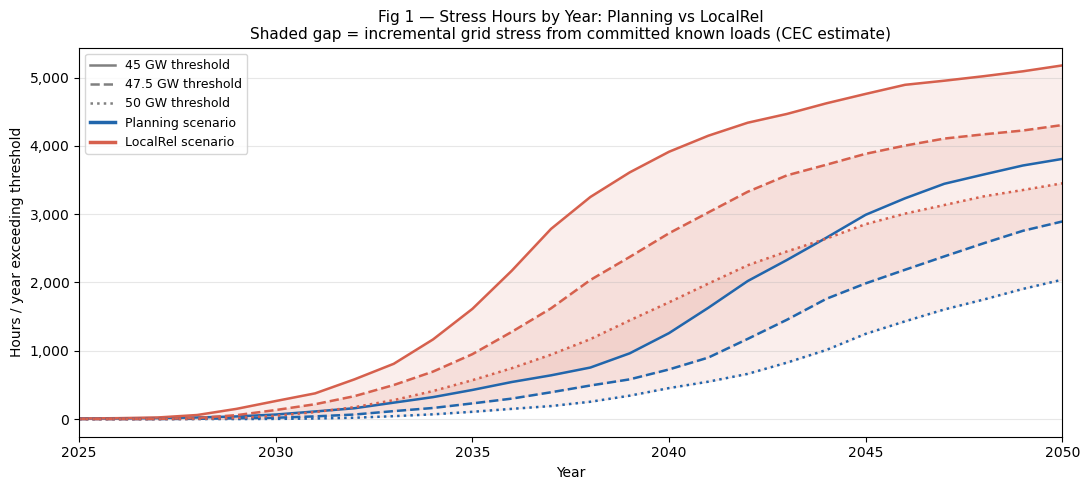

In [ ]:
## Fig 1: Threshold Hours by Year — Planning vs LocalRel
#
# Hours/year that MANAGED_NET_LOAD exceeds each stress threshold.
# The shaded gap between LocalRel and Planning is the CEC's own estimate
# of incremental grid stress from committed data center and known-load projects.

COLORS = {'Planning': '#2166ac', 'LocalRel': '#d6604d'}
THRESH_STYLES = {'45 GW': '-', '47.5 GW': '--', '50 GW': ':'}

fig, ax = plt.subplots(figsize=(11, 5))

years = thresh_by_scenario['Planning'].index

for thresh_name, ls in THRESH_STYLES.items():
    plan_hrs = thresh_by_scenario['Planning'][thresh_name]
    lrel_hrs = thresh_by_scenario['LocalRel'][thresh_name]

    ax.plot(years, plan_hrs, color=COLORS['Planning'], ls=ls, lw=1.8, label=f'Planning {thresh_name}')
    ax.plot(years, lrel_hrs, color=COLORS['LocalRel'], ls=ls, lw=1.8, label=f'LocalRel {thresh_name}')
    ax.fill_between(years, plan_hrs, lrel_hrs, color=COLORS['LocalRel'], alpha=0.10)

ax.set_xlabel('Year')
ax.set_ylabel('Hours / year exceeding threshold')
ax.set_title('Fig 1 — Stress Hours by Year: Planning vs LocalRel\n'
             'Shaded gap = incremental grid stress from committed known loads (CEC estimate)', fontsize=11)
ax.set_xlim(2025, 2050)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Custom legend: threshold line styles + scenario colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', ls='-',  lw=1.8, label='45 GW threshold'),
    Line2D([0], [0], color='gray', ls='--', lw=1.8, label='47.5 GW threshold'),
    Line2D([0], [0], color='gray', ls=':',  lw=1.8, label='50 GW threshold'),
    Line2D([0], [0], color=COLORS['Planning'], lw=2.5, label='Planning scenario'),
    Line2D([0], [0], color=COLORS['LocalRel'], lw=2.5, label='LocalRel scenario'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

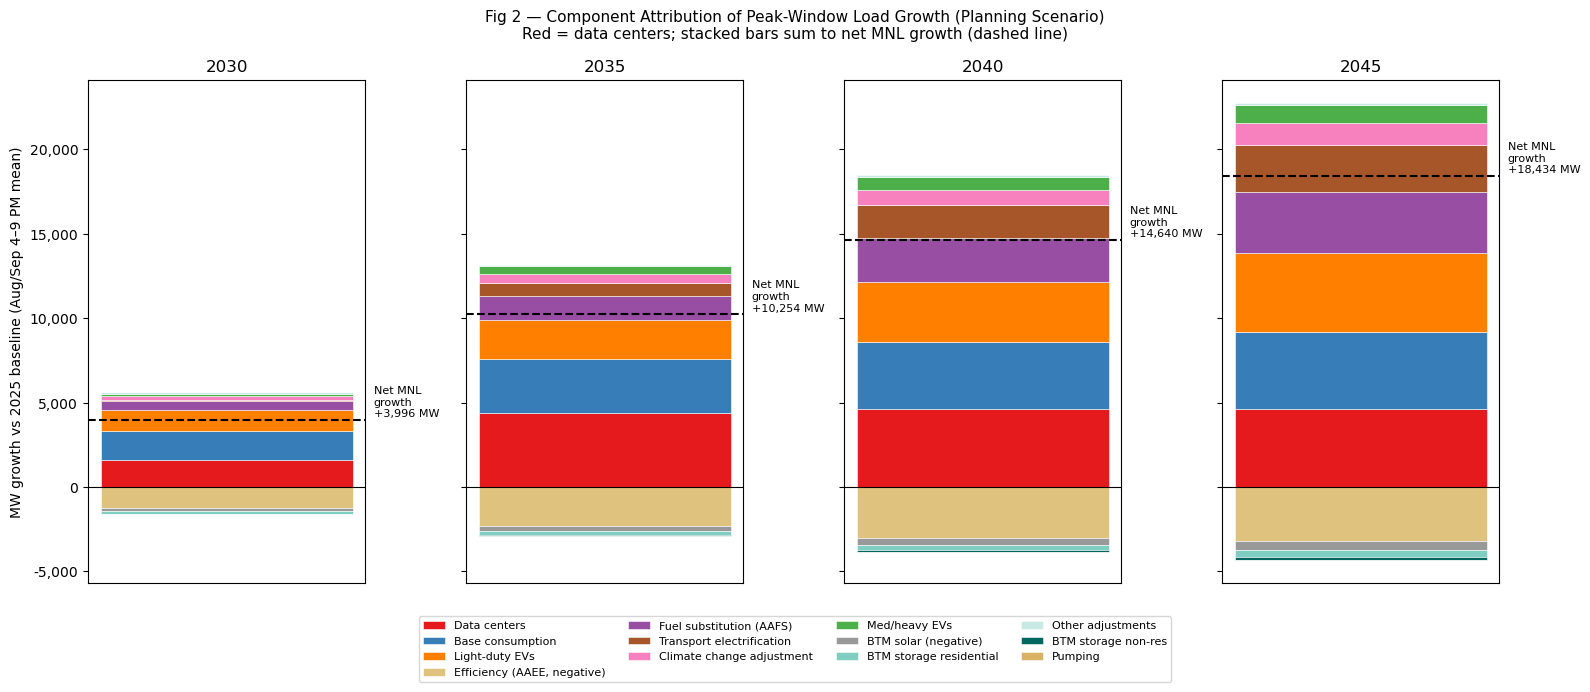

In [ ]:
## Fig 2: Component Waterfall — Aug/Sep 4–9 PM window, MW growth vs 2025 baseline
#
# Stacked bar chart: which components are driving peak-window load growth?
# Planning scenario only; sorted by 2040 absolute magnitude.
# Positive bars add to load; negative bars (AAEE, BTM_PV, storage) reduce it.

COMP_LABELS = {
    'UNADJUSTED_CONSUMPTION': 'Base consumption',
    'DATA_CENTER':             'Data centers',
    'LIGHT_EV':                'Light-duty EVs',
    'AAFS':                    'Fuel substitution (AAFS)',
    'AATE_LDV':                'Transport electrification',
    'CLIMATE_CHANGE':          'Climate change adjustment',
    'MEDIUM_HEAVY_EV':         'Med/heavy EVs',
    'BTM_PV':                  'BTM solar (negative)',
    'AAEE':                    'Efficiency (AAEE, negative)',
    'BTM_STORAGE_RES':         'BTM storage residential',
    'BTM_STORAGE_NONRES':      'BTM storage non-res',
    'OTHER_ADJUSTMENTS':       'Other adjustments',
    'PUMPING':                 'Pumping',
}

COMP_COLORS = {
    'Data centers':                '#e41a1c',
    'Base consumption':            '#377eb8',
    'Light-duty EVs':              '#ff7f00',
    'Fuel substitution (AAFS)':    '#984ea3',
    'Transport electrification':   '#a65628',
    'Climate change adjustment':   '#f781bf',
    'Med/heavy EVs':               '#4daf4a',
    'BTM solar (negative)':        '#999999',
    'Efficiency (AAEE, negative)': '#dfc27d',
    'BTM storage residential':     '#80cdc1',
    'BTM storage non-res':         '#01665e',
    'Other adjustments':           '#c7eae5',
    'Pumping':                     '#d8b365',
}

snapshot_plot_years = [2030, 2035, 2040, 2045]
g_plan = growth['Planning']

# Rank components by absolute magnitude at 2040
rank_order = g_plan.loc[2040, list(COMP_LABELS.keys())].abs().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, len(snapshot_plot_years), figsize=(16, 6), sharey=True)

for ax, yr in zip(axes, snapshot_plot_years):
    vals = g_plan.loc[yr, rank_order]
    labels = [COMP_LABELS[c] for c in rank_order]
    colors = [COMP_COLORS[l] for l in labels]

    pos_bottom = neg_bottom = 0
    for val, label, color in zip(vals, labels, colors):
        if val >= 0:
            ax.bar(0, val, bottom=pos_bottom, color=color, label=label, width=0.6, edgecolor='white', linewidth=0.4)
            pos_bottom += val
        else:
            ax.bar(0, val, bottom=neg_bottom, color=color, label=label, width=0.6, edgecolor='white', linewidth=0.4)
            neg_bottom += val

    ax.axhline(0, color='black', lw=0.8)
    mnl_g = g_plan.loc[yr, 'MANAGED_NET_LOAD']
    ax.axhline(mnl_g, color='black', lw=1.5, ls='--')
    ax.text(0.35, mnl_g + 50, f'Net MNL\ngrowth\n{mnl_g:+,.0f} MW', fontsize=8, va='bottom')
    ax.set_title(str(yr), fontsize=12)
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[0].set_ylabel('MW growth vs 2025 baseline (Aug/Sep 4–9 PM mean)')
fig.suptitle('Fig 2 — Component Attribution of Peak-Window Load Growth (Planning Scenario)\n'
             'Red = data centers; stacked bars sum to net MNL growth (dashed line)', fontsize=11)

handles, labels_leg = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.15), frameon=True)
plt.tight_layout()
plt.show()

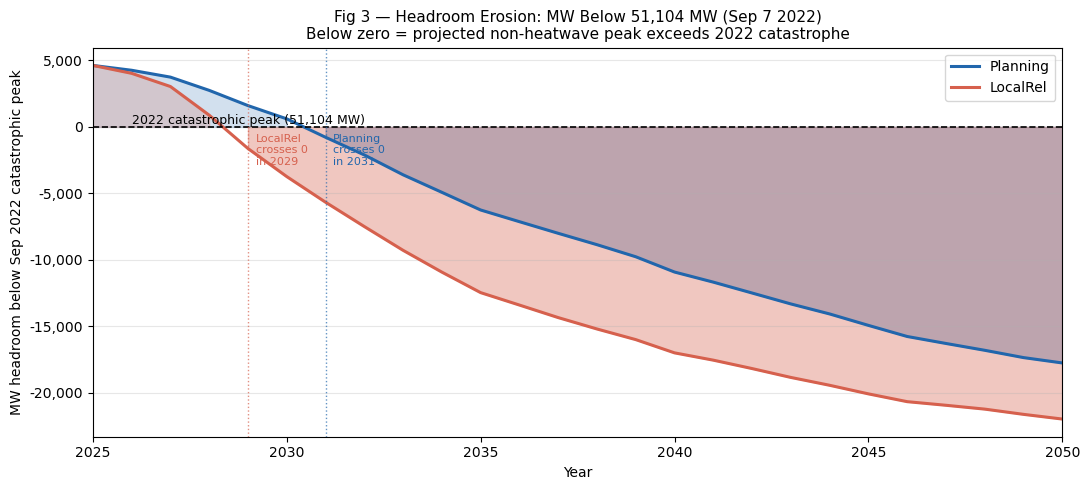

In [ ]:
## Fig 3: Headroom Erosion
#
# MW remaining below the 2022 catastrophic peak (51,104 MW) at each year's projected annual peak.
# Zero line = projected baseline equals the 2022 catastrophe with NO weather anomaly.
# Annotations mark the crossover years for each scenario.

fig, ax = plt.subplots(figsize=(11, 5))

years_all = headroom.index

ax.fill_between(years_all,
                headroom['Planning headroom (MW)'],
                0,
                where=headroom['Planning headroom (MW)'] > 0,
                color=COLORS['Planning'], alpha=0.20)
ax.fill_between(years_all,
                headroom['Planning headroom (MW)'],
                0,
                where=headroom['Planning headroom (MW)'] < 0,
                color=COLORS['Planning'], alpha=0.35)

ax.fill_between(years_all,
                headroom['LocalRel headroom (MW)'],
                0,
                where=headroom['LocalRel headroom (MW)'] > 0,
                color=COLORS['LocalRel'], alpha=0.20)
ax.fill_between(years_all,
                headroom['LocalRel headroom (MW)'],
                0,
                where=headroom['LocalRel headroom (MW)'] < 0,
                color=COLORS['LocalRel'], alpha=0.35)

ax.plot(years_all, headroom['Planning headroom (MW)'], color=COLORS['Planning'], lw=2.2, label='Planning')
ax.plot(years_all, headroom['LocalRel headroom (MW)'], color=COLORS['LocalRel'], lw=2.2, label='LocalRel')

ax.axhline(0, color='black', lw=1.2, ls='--')
ax.text(2026, 200, '2022 catastrophic peak (51,104 MW)', fontsize=9, color='black')

# Crossover annotations
for scenario_label, col_name, color in [
    ('Planning', 'Planning headroom (MW)', COLORS['Planning']),
    ('LocalRel',  'LocalRel headroom (MW)',  COLORS['LocalRel']),
]:
    cross = (headroom[col_name] < 0)
    if cross.any():
        yr = cross.idxmax()
        ax.axvline(yr, color=color, lw=1, ls=':', alpha=0.7)
        ax.text(yr + 0.2, -500, f'{scenario_label}\ncrosses 0\nin {yr}', fontsize=8, color=color, va='top')

ax.set_xlabel('Year')
ax.set_ylabel('MW headroom below Sep 2022 catastrophic peak')
ax.set_title('Fig 3 — Headroom Erosion: MW Below 51,104 MW (Sep 7 2022)\n'
             'Below zero = projected non-heatwave peak exceeds 2022 catastrophe', fontsize=11)
ax.set_xlim(2025, 2050)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

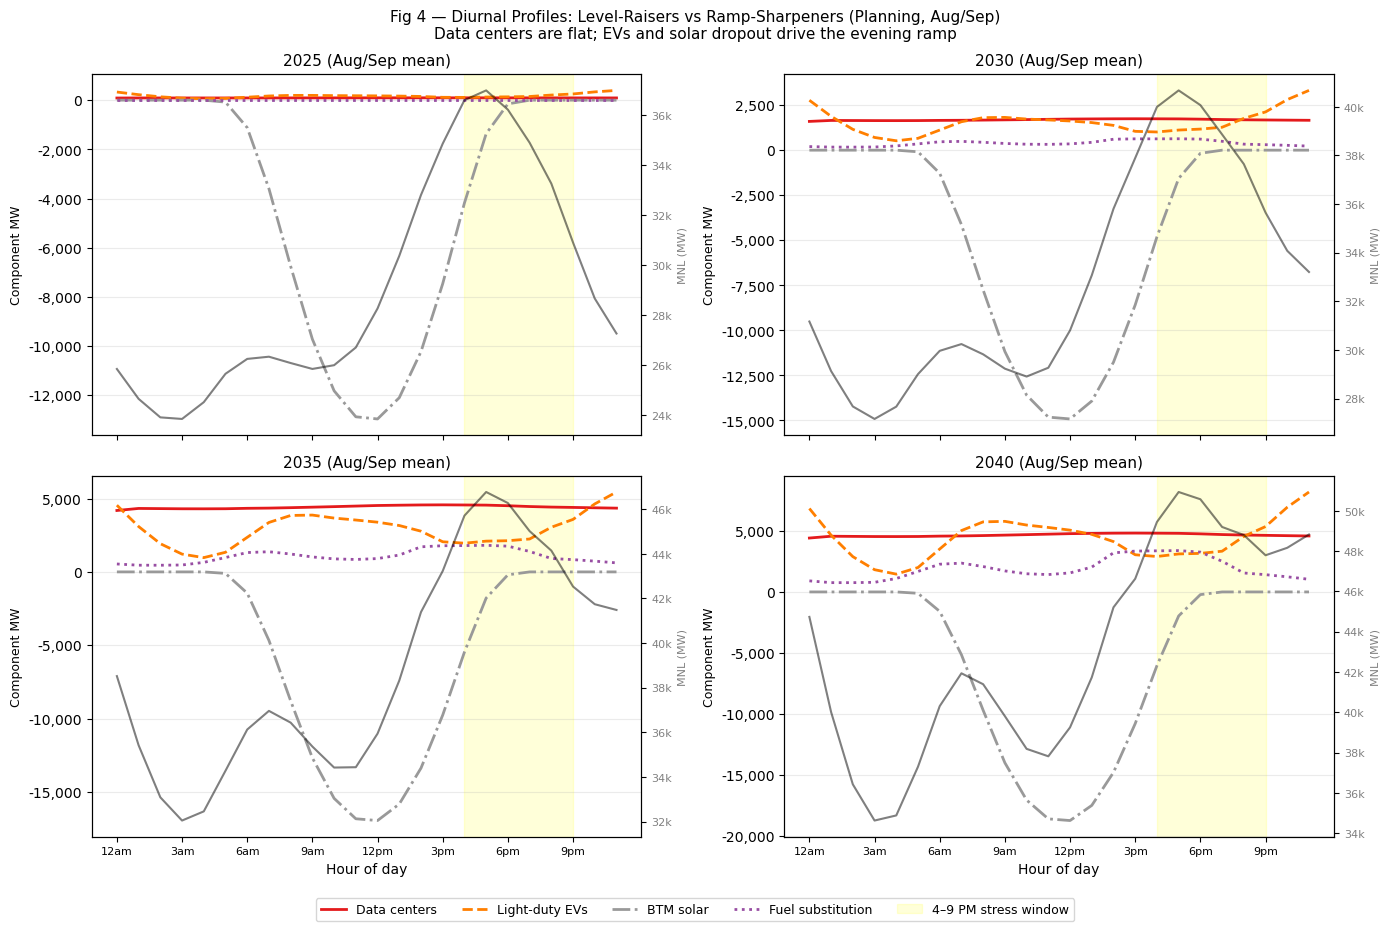

In [ ]:
## Fig 4: Diurnal Profiles — Level-Raiser vs Ramp-Sharpener
#
# Four-panel plot (one per snapshot year): Aug/Sep hourly mean MW for key components.
# DATA_CENTER is flat → level-raiser.
# LIGHT_EV peaks in early evening, BTM_PV drops off → ramp-sharpeners.
# MANAGED_NET_LOAD shown on secondary axis to show the duck-curve shape.

RAMP_PLOT_COMPONENTS = {
    'DATA_CENTER': ('Data centers', '#e41a1c', '-'),
    'LIGHT_EV':    ('Light-duty EVs', '#ff7f00', '--'),
    'BTM_PV':      ('BTM solar', '#999999', '-.'),
    'AAFS':        ('Fuel substitution', '#984ea3', ':'),
}

plot_years_diurnal = [2025, 2030, 2035, 2040]
hours_label = [f'{h % 12 or 12}{"am" if h < 12 else "pm"}' for h in range(24)]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for ax, yr in zip(axes, plot_years_diurnal):
    prof = diurnal_profiles[yr]
    x = range(1, 25)

    for col, (label, color, ls) in RAMP_PLOT_COMPONENTS.items():
        ax.plot(x, prof[col], color=color, ls=ls, lw=2, label=label)

    # MNL on secondary axis
    ax2 = ax.twinx()
    ax2.plot(x, prof['MANAGED_NET_LOAD'], color='black', lw=1.5, alpha=0.5, label='MNL (right axis)')
    ax2.set_ylabel('MNL (MW)', fontsize=8, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray', labelsize=8)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000):.0f}k'))

    # Shade peak stress window 17–22
    ax.axvspan(17, 22, color='yellow', alpha=0.15, label='4–9 PM stress window')
    ax.set_title(f'{yr} (Aug/Sep mean)', fontsize=11)
    ax.set_ylabel('Component MW', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(axis='y', alpha=0.25)

for ax in axes[2:]:
    ax.set_xlabel('Hour of day')
    ax.set_xticks(range(1, 25, 3))
    ax.set_xticklabels([hours_label[h - 1] for h in range(1, 25, 3)], fontsize=8)

# Unified legend below
handles_main, labels_main = axes[0].get_legend_handles_labels()
fig.legend(handles_main, labels_main, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), frameon=True)
fig.suptitle('Fig 4 — Diurnal Profiles: Level-Raisers vs Ramp-Sharpeners (Planning, Aug/Sep)\n'
             'Data centers are flat; EVs and solar dropout drive the evening ramp', fontsize=11)
plt.tight_layout()
plt.show()

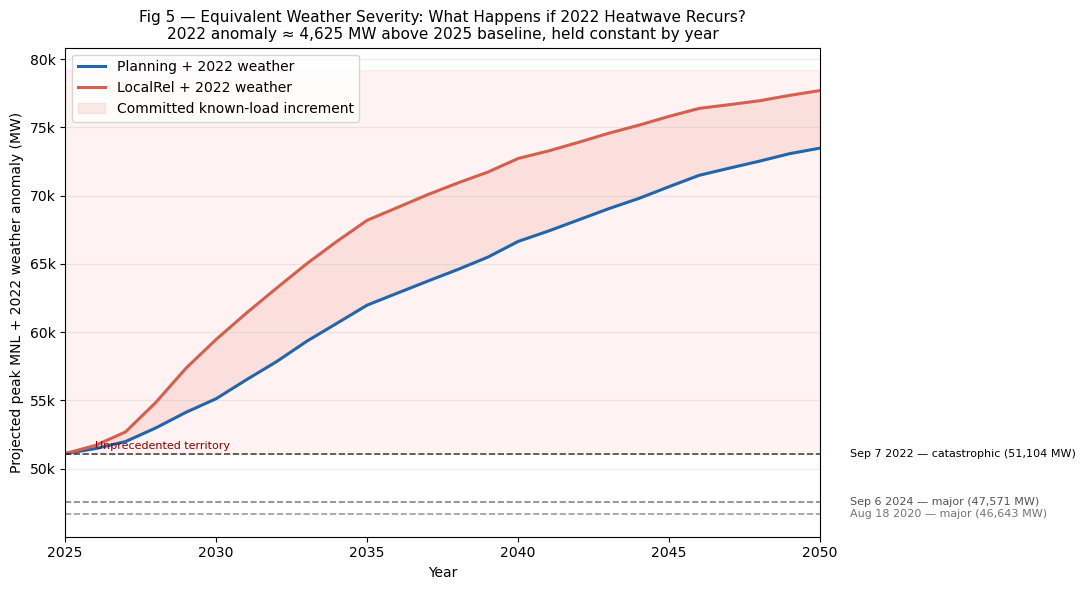

In [ ]:
## Fig 5: Equivalent Weather Severity — Projected MNL + 2022 Anomaly
#
# If the 2022 heatwave recurs, how high does the grid go each year?
# The 2022 weather anomaly (~4,625 MW above 2025 baseline) is held constant.
# Horizontal reference lines show historical event levels.
# All values above 51,104 MW are unprecedented territory.

fig, ax = plt.subplots(figsize=(11, 6))

equiv_plan = annual_peaks['Planning'] + weather_anomaly_2022
equiv_lrel = annual_peaks['LocalRel'] + weather_anomaly_2022

ax.plot(annual_peaks.index, equiv_plan, color=COLORS['Planning'], lw=2.2, label='Planning + 2022 weather')
ax.plot(annual_peaks.index, equiv_lrel, color=COLORS['LocalRel'],  lw=2.2, label='LocalRel + 2022 weather')
ax.fill_between(annual_peaks.index, equiv_plan, equiv_lrel, color=COLORS['LocalRel'], alpha=0.12,
                label='Committed known-load increment')

# Historical reference lines
REF_LINES = [
    (51_104, '#000000', 'Sep 7 2022 — catastrophic (51,104 MW)'),
    (47_571, '#525252', 'Sep 6 2024 — major (47,571 MW)'),
    (46_643, '#737373', 'Aug 18 2020 — major (46,643 MW)'),
]
for mw, color, label in REF_LINES:
    ax.axhline(mw, color=color, lw=1.2, ls='--', alpha=0.7)
    ax.text(2051, mw, label, fontsize=8, color=color, va='center', clip_on=False)

# Shade "unprecedented" zone above 2022 catastrophic
ax.axhspan(HIST_CATASTROPHIC_MW, ax.get_ylim()[1] if ax.get_ylim()[1] > HIST_CATASTROPHIC_MW else 80000,
           color='red', alpha=0.05)
ax.text(2026, HIST_CATASTROPHIC_MW + 300, 'Unprecedented territory', fontsize=8, color='darkred')

ax.set_xlabel('Year')
ax.set_ylabel('Projected peak MNL + 2022 weather anomaly (MW)')
ax.set_title('Fig 5 — Equivalent Weather Severity: What Happens if 2022 Heatwave Recurs?\n'
             f'2022 anomaly ≈ {weather_anomaly_2022:,.0f} MW above 2025 baseline, held constant by year', fontsize=11)
ax.set_xlim(2025, 2050)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000):.0f}k'))
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()